# Effect Size Analysis
วัดขนาดความแตกต่างของแต่ละ feature ระหว่างกลุ่ม `Non-Churn` และ `Churn` เพื่อดูว่า feature ที่สำคัญทางธุรกิจและทางสถิติมีแรงมากน้อยแค่ไหน

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import mannwhitneyu

palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
level_order = ['Strong', 'Moderate', 'Weak', 'None']

sns.set_theme(style='whitegrid')

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')
df_importance = pd.read_csv('../../../Data/processed/feature_importance.csv', keep_default_na=False)
df_importance['importance_level'] = pd.Categorical(
    df_importance['importance_level'],
    categories=level_order,
    ordered=True
)
df_importance = df_importance.sort_values('importance', ascending=False).reset_index(drop=True)

numeric_features = [
    column for column in df.select_dtypes(include=['number']).columns
    if column != 'Churned'
]

def cohen_d(group_0, group_1):
    n0, n1 = len(group_0), len(group_1)
    var0 = np.var(group_0, ddof=1)
    var1 = np.var(group_1, ddof=1)
    pooled_sd = np.sqrt(((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2))
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return 0.0
    return (group_1.mean() - group_0.mean()) / pooled_sd

def effect_magnitude(value):
    abs_value = abs(value)
    if abs_value >= 0.8:
        return 'Large'
    if abs_value >= 0.5:
        return 'Medium'
    if abs_value >= 0.2:
        return 'Small'
    return 'Negligible'

def rank_magnitude(value):
    abs_value = abs(value)
    if abs_value >= 0.5:
        return 'Large'
    if abs_value >= 0.3:
        return 'Medium'
    if abs_value >= 0.1:
        return 'Small'
    return 'Negligible'

def build_effect_size_table():
    rows = []
    for feature in numeric_features:
        non_churn = df.loc[df['Churned'] == 0, feature].dropna()
        churn = df.loc[df['Churned'] == 1, feature].dropna()
        u_statistic, p_value = mannwhitneyu(churn, non_churn, alternative='two-sided')
        auc_probability = u_statistic / (len(churn) * len(non_churn))
        rank_biserial = 2 * auc_probability - 1
        d_value = cohen_d(non_churn, churn)

        rows.append({
            'feature': feature,
            'importance': df_importance.loc[df_importance['feature'] == feature, 'importance'].iloc[0],
            'importance_level': df_importance.loc[df_importance['feature'] == feature, 'importance_level'].iloc[0],
            'mean_non_churn': non_churn.mean(),
            'mean_churn': churn.mean(),
            'mean_gap': churn.mean() - non_churn.mean(),
            'median_non_churn': non_churn.median(),
            'median_churn': churn.median(),
            'median_gap': churn.median() - non_churn.median(),
            'cohen_d': d_value,
            'cohen_magnitude': effect_magnitude(d_value),
            'rank_biserial': rank_biserial,
            'rank_magnitude': rank_magnitude(rank_biserial),
            'p_value': p_value
        })
    return pd.DataFrame(rows).sort_values('importance', ascending=False).reset_index(drop=True)

effect_size_df = build_effect_size_table()

## Top Effect Sizes
ดูว่า feature ใดมีขนาดความต่างระหว่าง churn กับ non-churn สูงจริง แม้ยังไม่สนใจตัวโมเดล

,feature,importance_level,importance,mean_gap,median_gap,cohen_d,cohen_magnitude,rank_biserial,rank_magnitude,p_value
0,Lifetime_Value,Strong,0.1290,-21.38,-134.06,-0.024,Negligible,-0.070,Negligible,3.9057e-35
1,Customer_Service_Calls,Strong,0.1279,1.71,2.00,0.669,Medium,0.378,Medium,0.0000e+00
2,Cart_Abandonment_Rate,Strong,0.0991,9.99,11.10,0.642,Medium,0.356,Medium,0.0000e+00
3,Discount_Usage_Rate,Strong,0.0715,-3.37,-1.60,-0.167,Negligible,-0.103,Small,1.4742e-72
4,Age,Strong,0.0685,-2.51,-1.00,-0.226,Small,-0.126,Small,6.9603e-109
5,Days_Since_Last_Purchase,Strong,0.0609,9.43,3.00,0.330,Small,0.165,Small,5.8460e-185
6,Total_Purchases,Moderate,0.0556,-2.48,-3.00,-0.358,Small,-0.239,Small,0.0000e+00
7,Email_Open_Rate,Moderate,0.0473,-6.63,-6.20,-0.489,Small,-0.287,Small,0.0000e+00
8,Average_Order_Value,Moderate,0.0473,16.38,15.46,0.093,Negligible,0.193,Small,2.2416e-252
9,Session_Duration_Avg,Moderate,0.0408,-5.08,-3.80,-0.496,Small,-0.280,Small,0.0000e+00


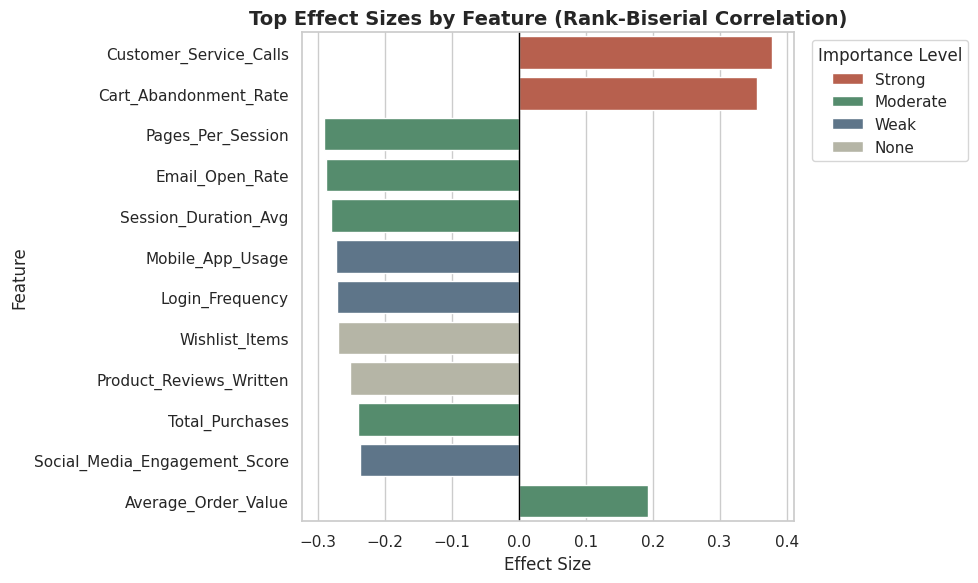

In [4]:
effect_display = effect_size_df.assign(
    importance=effect_size_df['importance'].round(4),
    mean_gap=effect_size_df['mean_gap'].round(2),
    median_gap=effect_size_df['median_gap'].round(2),
    cohen_d=effect_size_df['cohen_d'].round(3),
    rank_biserial=effect_size_df['rank_biserial'].round(3),
    p_value=effect_size_df['p_value'].map(lambda value: f'{value:.4e}')
)

display(
    effect_display[['feature', 'importance_level', 'importance', 'mean_gap', 'median_gap', 'cohen_d', 'cohen_magnitude', 'rank_biserial', 'rank_magnitude', 'p_value']]
)

plot_effect = effect_size_df.copy()
plot_effect['abs_rank_biserial'] = plot_effect['rank_biserial'].abs()
plot_effect = plot_effect.sort_values('abs_rank_biserial', ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_effect,
    y='feature',
    x='rank_biserial',
    hue='importance_level',
    dodge=False,
    palette=palette_level
)
plt.axvline(0, color='black', linewidth=1)
plt.title('Top Effect Sizes by Feature (Rank-Biserial Correlation)', fontsize=14, weight='bold')
plt.xlabel('Effect Size')
plt.ylabel('Feature')
plt.legend(title='Importance Level', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
effect_size_df.to_csv('../../../Data/processed/effect_size_summary.csv', index=False)
print('Saved effect size summary to Data/processed/effect_size_summary.csv')

Saved effect size summary to Data/processed/effect_size_summary.csv


## Practical Reading Guide
- ค่า `cohen_d` บอกขนาดความต่างในเชิง standardized mean difference
- ค่า `rank_biserial` บอกทิศทางและแรงของความต่างแบบ non-parametric
- ถ้า effect size ใหญ่และ importance สูง แปลว่า feature นั้นน่าสนใจทั้งในเชิง data และเชิง model